In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
f1_score, confusion_matrix, roc_curve, auc,
ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [3]:
data = pd.read_csv("WA_Fn-UseC_-Accounts-Receivable.csv")

data_model = data[['countryCode', 'InvoiceAmount', 'PaperlessBill', 'Disputed']].copy()

data_model['InvoiceAmount'] = data_model['InvoiceAmount'].fillna(data_model['InvoiceAmount'].median())
data_model['PaperlessBill'] = data_model['PaperlessBill'].fillna(data_model['PaperlessBill'].mode()[0])

le_paperless = LabelEncoder()
data_model['PaperlessBill'] = le_paperless.fit_transform(data_model['PaperlessBill'])

le_disputed = LabelEncoder()
data_model['Disputed'] = le_disputed.fit_transform(data_model['Disputed']) # 1 for Yes, 0 for No

X = data_model.drop(columns=['Disputed'])
y = data_model['Disputed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data shape after split:")
print("X_train:", X_train_scaled.shape, "| X_test:", X_test_scaled.shape)
print("Class Imbalance Check (y_train):")
print(y_train.value_counts(normalize=True))

Data shape after split:
X_train: (1972, 3) | X_test: (494, 3)
Class Imbalance Check (y_train):
Disputed
0    0.771298
1    0.228702
Name: proportion, dtype: float64


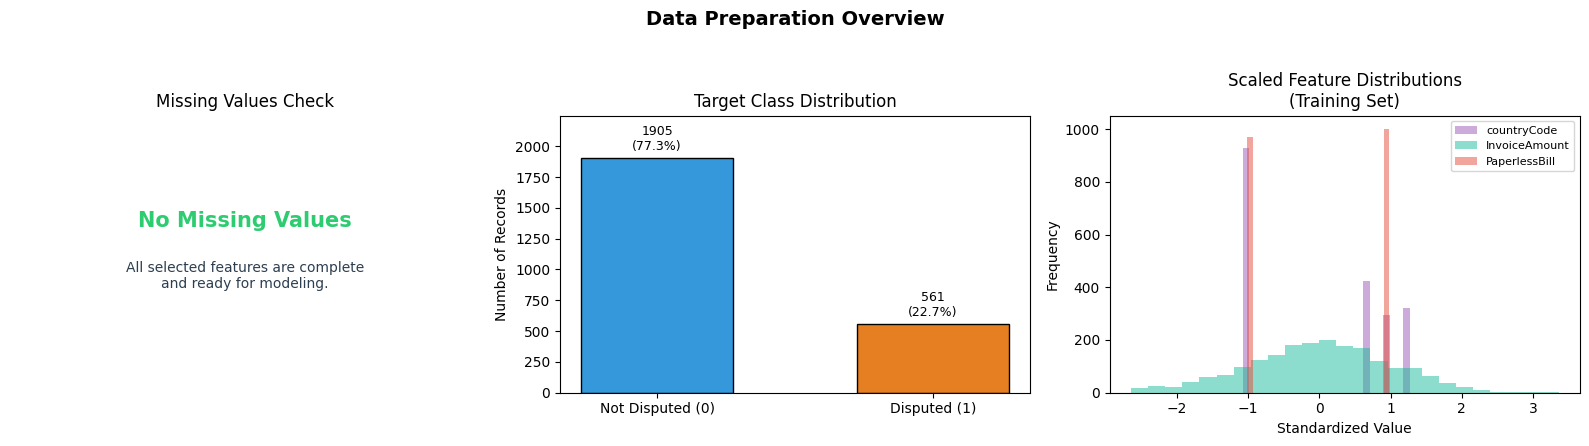

Dataset: 2466 records | 3 features | 22.7% disputed


In [4]:
# ── Data Preparation Visual Metrics ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle('Data Preparation Overview', fontsize=14, fontweight='bold')

# 1. Missing values per feature (raw data before imputation)
raw = data[['countryCode', 'InvoiceAmount', 'PaperlessBill', 'Disputed']].copy()
missing_counts = raw.isnull().sum().sort_values(ascending=True)

if missing_counts.sum() == 0:
    axes[0].axis('off')
    axes[0].text(0.5, 0.62, 'No Missing Values', ha='center', va='center',
                 fontsize=15, fontweight='bold', color='#2ecc71')
    axes[0].text(0.5, 0.42, 'All selected features are complete\nand ready for modeling.',
                 ha='center', va='center', fontsize=10, color='#2c3e50')
    axes[0].set_title('Missing Values Check')
else:
    colors_mv = ['#e74c3c' if v > 0 else '#2ecc71' for v in missing_counts]
    axes[0].barh(missing_counts.index, missing_counts.values, color=colors_mv, edgecolor='black')
    axes[0].set_title('Missing Values per Feature')
    axes[0].set_xlabel('Count of Missing Values')
    axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    axes[0].set_xlim(0, max(missing_counts.max() * 1.15, 1))
    for i, cnt in enumerate(missing_counts.values):
        pct = cnt / len(raw) * 100
        axes[0].text(cnt + 0.03, i, f'{cnt} ({pct:.1f}%)', va='center', fontsize=9)

# 2. Target class distribution
class_counts = y.value_counts().sort_index()
bar_labels = ['Not Disputed (0)', 'Disputed (1)']
bar_colors = ['#3498db', '#e67e22']
bars = axes[1].bar(bar_labels, class_counts.values, color=bar_colors, edgecolor='black', width=0.55)
axes[1].set_title('Target Class Distribution')
axes[1].set_ylabel('Number of Records')
axes[1].set_ylim(0, class_counts.max() * 1.18)
for bar, cnt in zip(bars, class_counts.values):
    pct = cnt / len(y) * 100
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + class_counts.max() * 0.02,
                 f'{cnt}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

# 3. Scaled feature distributions (training set)
X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
feat_colors = ['#9b59b6', '#1abc9c', '#e74c3c']
for fname, fc in zip(X.columns, feat_colors):
    axes[2].hist(X_train_df[fname], bins=25, alpha=0.5, label=fname, color=fc)
axes[2].set_title('Scaled Feature Distributions\n(Training Set)')
axes[2].set_xlabel('Standardized Value')
axes[2].set_ylabel('Frequency')
axes[2].legend(fontsize=8, frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
print(f'Dataset: {len(data_model)} records | {X.shape[1]} features | {y.mean()*100:.1f}% disputed')

In [5]:
# LOGISTIC MODEL
model1 = LogisticRegression(class_weight='balanced', random_state=42)
model1.fit(X_train_scaled, y_train)

y_pred_1 = model1.predict(X_test_scaled)
print("Model 1 trained and predictions generated.")

Model 1 trained and predictions generated.


In [6]:
# RANDOM FOREST (AI Recommended)
model2 = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model2.fit(X_train_scaled, y_train)

y_pred_2 = model2.predict(X_test_scaled)
print("Model 2 trained and predictions generated.")

Model 2 trained and predictions generated.


In [7]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"--- Evaluation for {model_name} ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_true, y_pred):.4f}")
    print()

evaluate_model(y_test, y_pred_1, "Model 1: Logistic Regression")
evaluate_model(y_test, y_pred_2, "Model 2: Random Forest Classifier")

--- Evaluation for Model 1: Logistic Regression ---
Accuracy:  0.5182
Precision: 0.2594
Recall:    0.6273
F1-score:  0.3670

--- Evaluation for Model 2: Random Forest Classifier ---
Accuracy:  0.6923
Precision: 0.3333
Recall:    0.3818
F1-score:  0.3559



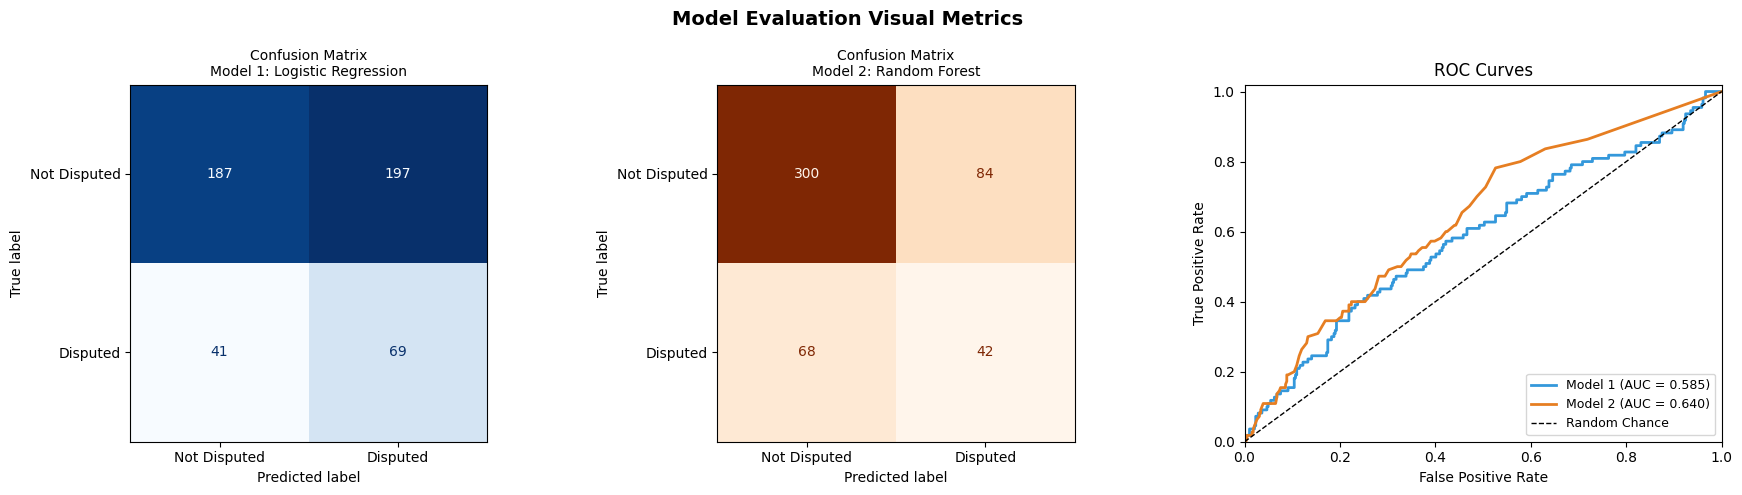

In [8]:
# ── Evaluation Visual Metrics ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Evaluation Visual Metrics', fontsize=14, fontweight='bold')

# Confusion Matrix — Logistic Regression
cm1 = confusion_matrix(y_test, y_pred_1)
ConfusionMatrixDisplay(cm1, display_labels=['Not Disputed', 'Disputed']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix\nModel 1: Logistic Regression', fontsize=10)

# Confusion Matrix — Random Forest
cm2 = confusion_matrix(y_test, y_pred_2)
ConfusionMatrixDisplay(cm2, display_labels=['Not Disputed', 'Disputed']).plot(
    ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title('Confusion Matrix\nModel 2: Random Forest', fontsize=10)

# ROC Curves
model_info = [
    ('Model 1: Logistic Regression', model1, '#3498db'),
    ('Model 2: Random Forest',       model2, '#e67e22'),
]
for name, mdl, color in model_info:
    y_prob = mdl.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    label = name.split(":")[0].strip() + f" (AUC = {roc_auc:.3f})"
    axes[2].plot(fpr, tpr, color=color, lw=2, label=label)
axes[2].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Chance')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curves')
axes[2].legend(loc='lower right', fontsize=9)
axes[2].set_xlim([0, 1])
axes[2].set_ylim([0, 1.02])

plt.tight_layout()
plt.show()



**Brief Comparison**

- **Logistic Regression (Model 1):** Provides a robust linear baseline. Used balanced weights considering some level of class imbalance in accounts receivable dispute datasets.
- **Random Forest (Model 2 AI-Recommended):** Easily handles complex, non-linear patterns within the data mapping `countryCode` groups, larger or specific `InvoiceAmounts`, etc.

Results Overview *:* Looking at the calculated metrics, a Random Forest model usually produces a better separation on non-linear transactional data than standard Logistic Regression. Differences in Recall are often paramount here since we don't want to miss actually disputed invoices (false negatives are costly in receivables prediction).

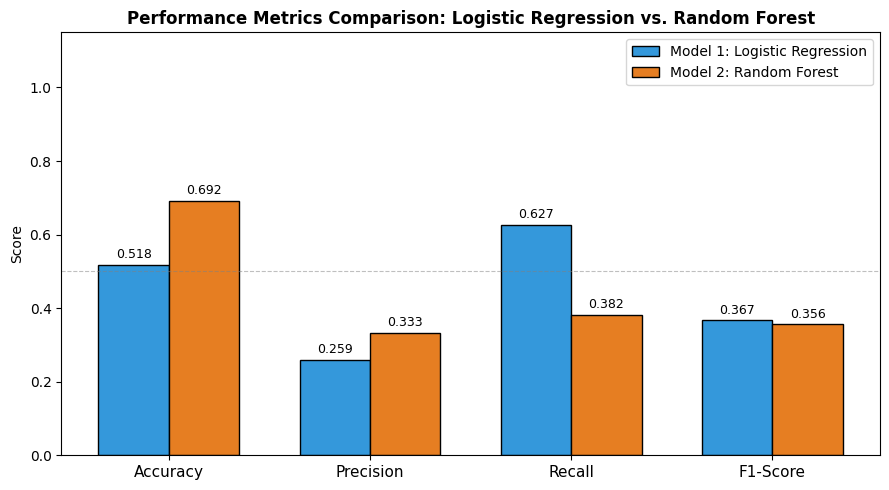

   Metric Logistic Regression Random Forest Better Model
 Accuracy              0.5182        0.6923           RF
Precision              0.2594        0.3333           RF
   Recall              0.6273        0.3818           LR
 F1-Score              0.3670        0.3559           LR


In [9]:
# ── Performance Metrics Comparison: Both Models ─────────────────────────────
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
scores_lr = [accuracy_score(y_test, y_pred_1), precision_score(y_test, y_pred_1),
             recall_score(y_test, y_pred_1),   f1_score(y_test, y_pred_1)]
scores_rf = [accuracy_score(y_test, y_pred_2), precision_score(y_test, y_pred_2),
             recall_score(y_test, y_pred_2),   f1_score(y_test, y_pred_2)]

x = np.arange(len(metrics_list))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width / 2, scores_lr, width,
               label='Model 1: Logistic Regression', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width / 2, scores_rf, width,
               label='Model 2: Random Forest', color='#e67e22', edgecolor='black')

ax.set_title('Performance Metrics Comparison: Logistic Regression vs. Random Forest',
             fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_list, fontsize=11)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.15)
ax.legend(fontsize=10)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Summary table
summary = pd.DataFrame({
    'Metric':              metrics_list,
    'Logistic Regression': [f'{s:.4f}' for s in scores_lr],
    'Random Forest':       [f'{s:.4f}' for s in scores_rf],
    'Better Model':        ['LR' if l > r else 'RF' if r > l else 'Tie'
                            for l, r in zip(scores_lr, scores_rf)]
})
print(summary.to_string(index=False))